In [74]:
# Data anaysis
import pandas as pd
import numpy as np

# Plotting and Correlation Maths
import seaborn as sns
import scipy as sci

# Simple model development
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier


import matplotlib.pyplot as plt

import plotly as px


import os

In [2]:
# get data
data = pd.read_csv('../data/processed/cleaned_data.csv')
data

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
1,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
2,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
3,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
4,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,68.8,58.9,61.6,68.8,58.9,61.6,56.7,84.8,1.526,83.33,...,0,0,0,0,1,0,0,0,0,0
3680,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,83.33,...,0,0,0,0,1,0,0,0,0,0
3681,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,12.50,...,0,0,0,0,1,0,0,0,0,0
3682,81.1,45.0,64.1,79.9,39.9,62.9,39.5,42.6,0.001,4.17,...,0,0,0,0,1,0,0,0,0,0


In [156]:
# Split the inputs and targets
#TODO:
# I need to remake the clean_data.csv file to inlcude the survive feature


# Uncomment when ready
# target = data['survive'].copy()
# inputs = data.drop('survive').copy()

KeyError: 'survive'

# Compute the SVD

Variance cutoff can be done around 15-17 features.  The plot shows the intersection at 95% variance and 16 S values.

This will allow us to drop around 10 features and still have reasonable outputs from the model.

In [82]:
# This will center and scale the dataset for PCA
scaler = StandardScaler()
scaled_inputs = scaler.fit_transform(inputs)
# Remake a DF so we can see the described data to ensure the scaler worked
scaled_inputs_df = pd.DataFrame(scaled_inputs, columns=data.columns)
scaled_inputs_df

In [ ]:
# Check for centering (mean = 0) and standardization
scaled_inputs_df.describe()

In [150]:
# Change the number of singular value components to see how much variance you'll be keeping
#  Max is 26; 15 gives us just under 95%.
n_comps = 26

# Create a PCA class and fit the model
pca = PCA(n_components=n_comps, svd_solver='full')
pca.fit(scaled_inputs)
# Transform via the PCA
inputs_pca = pca.transform(scaled_inputs)

In [151]:
inputs_pca.shape

(3684, 26)

In [152]:
sum(pca.explained_variance_ratio_)

0.9999999999999997

In [153]:
ratios = pca.explained_variance_ratio_
ratios

array([3.12153966e-01, 1.49714034e-01, 5.32266615e-02, 4.86726253e-02,
       4.38747450e-02, 4.00799217e-02, 3.90529992e-02, 3.88406266e-02,
       3.86568907e-02, 3.85179982e-02, 3.69338929e-02, 3.45821084e-02,
       2.95631471e-02, 2.39545825e-02, 2.13544917e-02, 1.73061978e-02,
       1.09391195e-02, 9.89087475e-03, 9.02133178e-03, 2.85703644e-03,
       3.45056424e-04, 2.59298002e-04, 1.32344369e-04, 5.53827795e-05,
       1.46667263e-05, 1.28314364e-32])

In [154]:
r_values = np.cumsum(ratios) / sum(ratios)
print(np.cumsum(ratios)/sum(ratios))

[0.31215397 0.461868   0.51509466 0.56376729 0.60764203 0.64772195
 0.68677495 0.72561558 0.76427247 0.80279047 0.83972436 0.87430647
 0.90386962 0.9278242  0.94917869 0.96648489 0.97742401 0.98731488
 0.99633622 0.99919325 0.99953831 0.99979761 0.99992995 0.99998533
 1.         1.        ]


<function matplotlib.pyplot.show(close=None, block=None)>

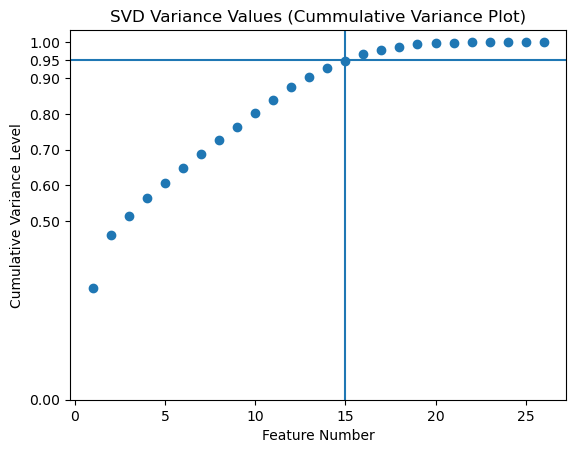

In [155]:
# Create plot; This will only make sense when n_comps = 26!
fig, ax = plt.subplots()
plt.scatter(range(1,len(r_values)+1),r_values)
plt.axhline(0.95)
plt.axvline(15)
plt.xlabel('Feature Number')
plt.ylabel('Cumulative Variance Level')
plt.title('SVD Variance Values (Cummulative Variance Plot)')

xt = [0, 5, 10, 15, 20, 25]
yt = [0,  0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
plt.xticks(ticks=xt)
plt.yticks(ticks=yt)

plt.show

# Time to Create a Model

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(inputs_pca, targets, test_size=0.2, random_state=42)


In [ ]:
#TODO: Either one-hot encode the 'survive' feature or leave it... might depend on the model built



In [ ]:
# Build your model

# Logistic Regression Setup via sklearn:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit
log_res = LogisticRegression()
log_res.fit(X_train, y_train)
log_res.predict(X_test, y_test) # Will give predictions for your own analysis
log_res.score(X_test, y_test)  # Will give mean accuracy on the test data and labels


# Random Forest Classifier Setup via sklearn:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
rf = RandomForestClassifier(n_estimators=100, criterion='entropy') # could use 'gini'
rf.fit(X_train, y_train)
rf.predict(X_test, y_test) # Will give predictions for your own analysis
rf.score(X_test, y_test)  # Will give mean accuracy on the test data and labels


# Neural Network Setup via sklearn: (if you wanted to toss this you could use TensorFlow or PyTorch.  doesn't matter to me)
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
nn = MLPClassifier(hidden_layer_sizes=(10,10,10), activation='relu', solver='adam')
nn.fit(X_train, y_train)
nn.predict(X_test, y_test) # Will give predictions for your own analysis
nn.score(X_test, y_test)  # Will give mean accuracy on the test data and labels
